/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_6185/6887058.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


                                                text  cluster
0  aarakocra https://www.aidedd.org/dnd/monstres....        0
1  abjurer  9 humanoid (any race) Medium  any ali...        3
2  aboleth https://www.aidedd.org/dnd/monstres.ph...        0
3  abominable-yeti  9 monstrosity Huge  chaotic e...        0
4  acererak  23 undead Medium  neutral evil  Adve...        0
5  acolyte https://www.aidedd.org/dnd/monstres.ph...        0
6  adult-black-dragon https://www.aidedd.org/dnd/...        4
7  adult-blue-dracolich  17 undead Huge fly lawfu...        0
8  adult-blue-dragon https://www.aidedd.org/dnd/m...        4
9  adult-brass-dragon https://www.aidedd.org/dnd/...        4


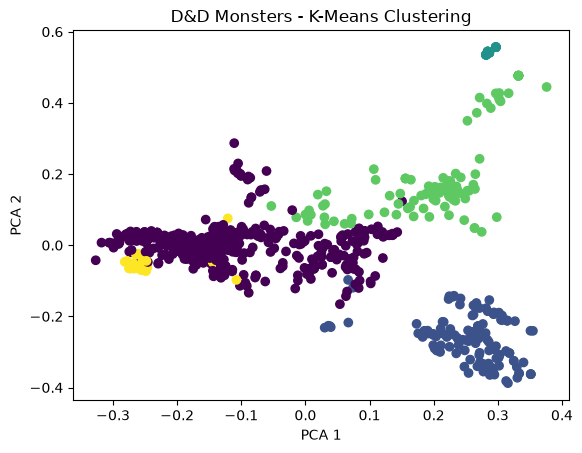

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("dnd_monsters.csv")

# Combine all text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1)

# NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
X = tfidf.fit_transform(df["text"])

# K-Means
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# Show results
print(df[["text", "cluster"]].head(10))

# PCA visualization
pca = PCA(n_components=2)
X2 = pca.fit_transform(X.toarray())

plt.scatter(X2[:, 0], X2[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("D&D Monsters - K-Means Clustering")
plt.show()

# Save results
df.to_csv("dnd_monsters_clustered.csv", index=False)